### Packages necessaires

In [46]:
#importation des bibliotheques necessaires
import numpy as numpy
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import missingno as msno
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from catboost import CatBoostRegressor
print("Bien importe")

Bien importe


In [47]:
#importation de la donnees
ckd = pd.read_csv("kidney_disease.csv")

In [48]:
ckd.head(20)

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd
5,5,60.0,90.0,1.015,3.0,0.0,NaN,NaN,notpresent,notpresent,...,39,7800,4.4,yes,yes,no,good,yes,no,ckd
6,6,68.0,70.0,1.010,0.0,0.0,NaN,normal,notpresent,notpresent,...,36,NaN,NaN,no,no,no,good,no,no,ckd
7,7,24.0,NaN,1.015,2.0,4.0,normal,abnormal,notpresent,notpresent,...,44,6900,5,no,yes,no,good,yes,no,ckd
8,8,52.0,100.0,1.015,3.0,0.0,normal,abnormal,present,notpresent,...,33,9600,4.0,yes,yes,no,good,no,yes,ckd
9,9,53.0,90.0,1.020,2.0,0.0,abnormal,abnormal,present,notpresent,...,29,12100,3.7,yes,yes,no,poor,no,yes,ckd


In [49]:
#infos generale sur la donnee 
ckd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

### Description des donnees

In [50]:
ckd.describe()

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
count,400.000000,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,115.614301,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,299.250000,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [51]:
#valeurs unique 
print(ckd.nunique().sort_values(ascending=False))

id                400
bgr               146
bu                118
hemo              115
wc                 90
sc                 84
age                76
rc                 49
pcv                43
pot                40
sod                34
bp                 10
su                  6
al                  6
sg                  5
ba                  2
pcc                 2
pc                  2
rbc                 2
htn                 2
dm                  2
cad                 2
appet               2
pe                  2
ane                 2
classification      2
dtype: int64


In [52]:
#affichage des valeurs manquants 
print(ckd.isnull().sum().sort_values(ascending=False))

rbc               152
rc                130
wc                105
pot                88
sod                87
pcv                70
pc                 65
hemo               52
su                 49
sg                 47
al                 46
bgr                44
bu                 19
sc                 17
bp                 12
age                 9
ba                  4
pcc                 4
htn                 2
dm                  2
cad                 2
ane                 1
appet               1
pe                  1
id                  0
classification      0
dtype: int64


In [53]:
#renommer les colonnes
new_col= ['id','age','pression_arterielle','gravite_specifique','albumine','sucre','globule','cellules_pus','agregation_pus','bacteries','glucose_sanguin','uree','creatinine','soduim','potassium','hemoglobine','volume_cellules','globules_blanc','globules_rouges','hypertension','diabete','maladie_coronarienne','appetit','oedeme_pieds','anemie','classification']

ckd.columns = new_col

ckd.head(200)

,id,age,pression_arterielle,gravite_specifique,albumine,sucre,globule,cellules_pus,agregation_pus,bacteries,...,volume_cellules,globules_blanc,globules_rouges,hypertension,diabete,maladie_coronarienne,appetit,oedeme_pieds,anemie,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,195,70.0,90.0,1.020,2.0,1.0,abnormal,abnormal,notpresent,present,...,NaN,NaN,NaN,yes,yes,yes,poor,no,no,ckd
196,196,49.0,100.0,1.010,3.0,0.0,abnormal,abnormal,notpresent,notpresent,...,24,9600,3.5,yes,yes,no,poor,yes,yes,ckd
197,197,57.0,80.0,NaN,NaN,NaN,NaN,NaN,notpresent,notpresent,...,NaN,4300,3.0,yes,yes,no,good,no,yes,ckd
198,198,59.0,100.0,1.020,4.0,2.0,normal,normal,notpresent,notpresent,...,30,26400,3.9,yes,yes,no,poor,yes,no,ckd


In [54]:
#supprimer la colonne id
colonne_id = ['id']
if 'id' in ckd.columns:
    ckd.drop('id', axis=1, inplace=True)
    print("Colonne 'id' supprimée du DataFrame.")

Colonne 'id' supprimée du DataFrame.


In [55]:
#identifier les valeurs non numerique et les remplacer par NaN 
ckd.replace(['\t?', '\t', '-', ' ', 'nan', 'N/A', ''], pd.NA, inplace=True)  

#Convertir les colonnes numériques
colonnes_numeriques = ['age', 'pression_arterielle','gravite_specifique', 'albumine', 'sucre', 'glucose_sanguin', 'uree', 'creatinine', 'soduim', 'potassium', 'hemoglobine', 'volume_cellules', 'globules_blanc', 'globules_rouges']
for col in colonnes_numeriques:
    ckd[col] = pd.to_numeric(ckd[col], errors='coerce') 
    
    # 'coerce' met NaN si impossible

# convertir les colonnes catégorielles
colonnes_categorielle = [
    'globule', 'cellules_pus', 'agregation_pus', 'bacteries', 
    'hypertension', 'diabete', 'maladie_coronarienne', 'appetit', 
    'oedeme_pieds', 'anemie', 'classification'
]
for col in colonnes_categorielle:
    ckd[col] = ckd[col].astype('category')

# Créer la COPIE de travail
ckd_clean = ckd.copy()

In [56]:
ckd_clean.head(10)

,age,pression_arterielle,gravite_specifique,albumine,sucre,globule,cellules_pus,agregation_pus,bacteries,glucose_sanguin,...,volume_cellules,globules_blanc,globules_rouges,hypertension,diabete,maladie_coronarienne,appetit,oedeme_pieds,anemie,classification
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd
5,60.0,90.0,1.015,3.0,0.0,NaN,NaN,notpresent,notpresent,74.0,...,39.0,7800.0,4.4,yes,yes,no,good,yes,no,ckd
6,68.0,70.0,1.010,0.0,0.0,NaN,normal,notpresent,notpresent,100.0,...,36.0,NaN,NaN,no,no,no,good,no,no,ckd
7,24.0,NaN,1.015,2.0,4.0,normal,abnormal,notpresent,notpresent,410.0,...,44.0,6900.0,5.0,no,yes,no,good,yes,no,ckd
8,52.0,100.0,1.015,3.0,0.0,normal,abnormal,present,notpresent,138.0,...,33.0,9600.0,4.0,yes,yes,no,good,no,yes,ckd
9,53.0,90.0,1.020,2.0,0.0,abnormal,abnormal,present,notpresent,70.0,...,29.0,12100.0,3.7,yes,yes,no,poor,no,yes,ckd


## Analyse Exploratoire

### Analyse Exploratoire Preliminaire avec les NaN

<function matplotlib.pyplot.show(close=None, block=None)>

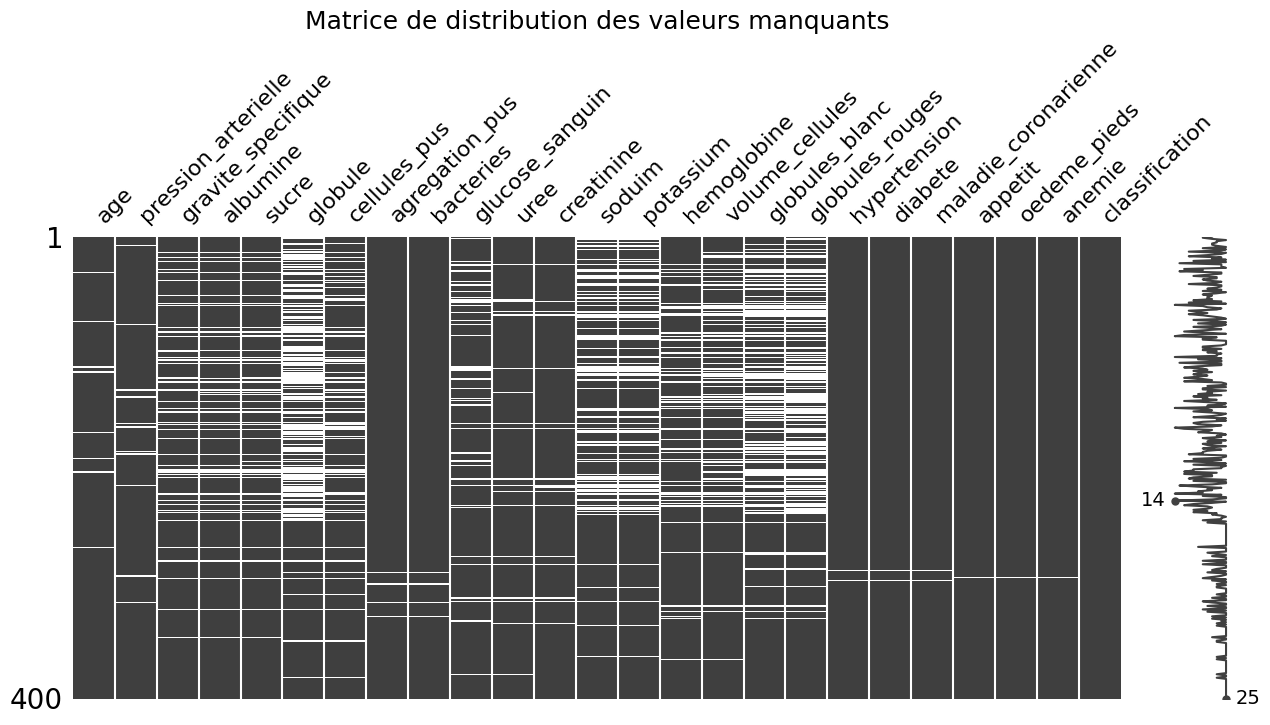

In [57]:
#matrice des valeurs manquantes
msno.matrix(ckd_clean,figsize=(15,6))
plt.title("Matrice de distribution des valeurs manquants",fontsize=18)
plt.show


#### Observation Clé : On observe de grandes lignes horizontales blanches dans la matrice, en particulier pour les variables centrales et les mesures sanguines (par exemple : globule, cellules_pus, glucose_sanguin, creatinine, hemoglobine, globules_blanc, globules_rouges).

#### Interprétation : Les données ne manquent pas au hasard. Ces valeurs manquent souvent ensemble sur les mêmes lignes (patients). C'est la signature d'un mécanisme MAR (Missing At Random - Manquant Aléatoire) : la raison pour laquelle une valeur manque est liée à la valeur connue d'une autre variable.

<function matplotlib.pyplot.show(close=None, block=None)>

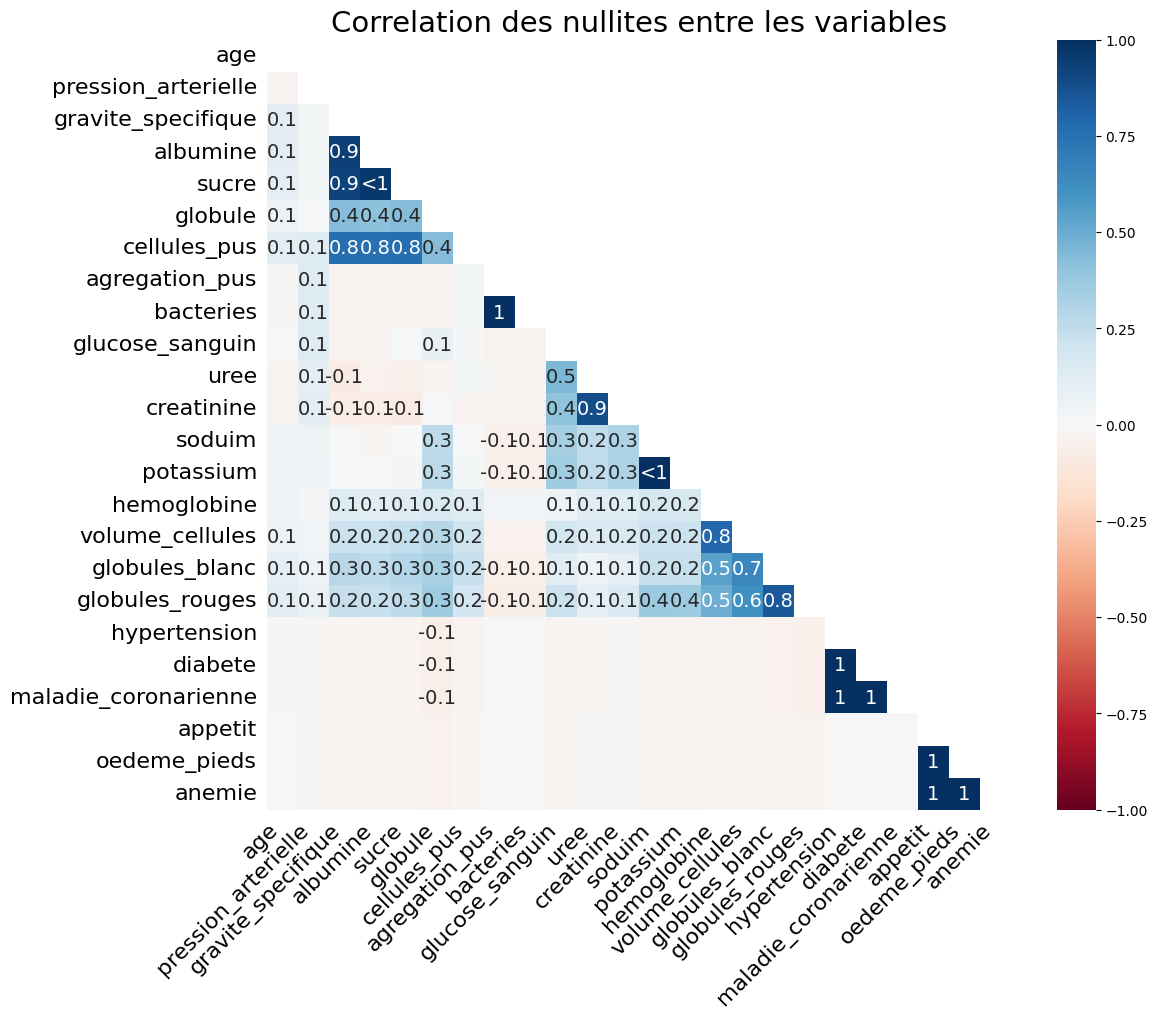

In [58]:
#Heatmap de correlation des nullites
msno.heatmap(ckd_clean,figsize=(12,10))
plt.title('Correlation des nullites entre les variables',fontsize=21) 
plt.show

Paire de Colonnes,Corrélation,Signification

Diabete / Hypertension,1.0 : "Si le statut diabete manque, le statut hypertension manque aussi sur la même ligne."

Albumine / Sucre,0.9 : Ces deux mesures manquent ensemble très fréquemment.

Volume Cellules / Hémoglobine : 0.8,Ces deux mesures hématologiques manquent souvent en même temps.

Cellules Pus / Globule,0.8 : "Si les informations sur les globules manquent, les informations sur les cellules_pus manquent aussi."

Anémie / Oedème Pieds : 1.0,Même situation que Diabète/Hypertension.

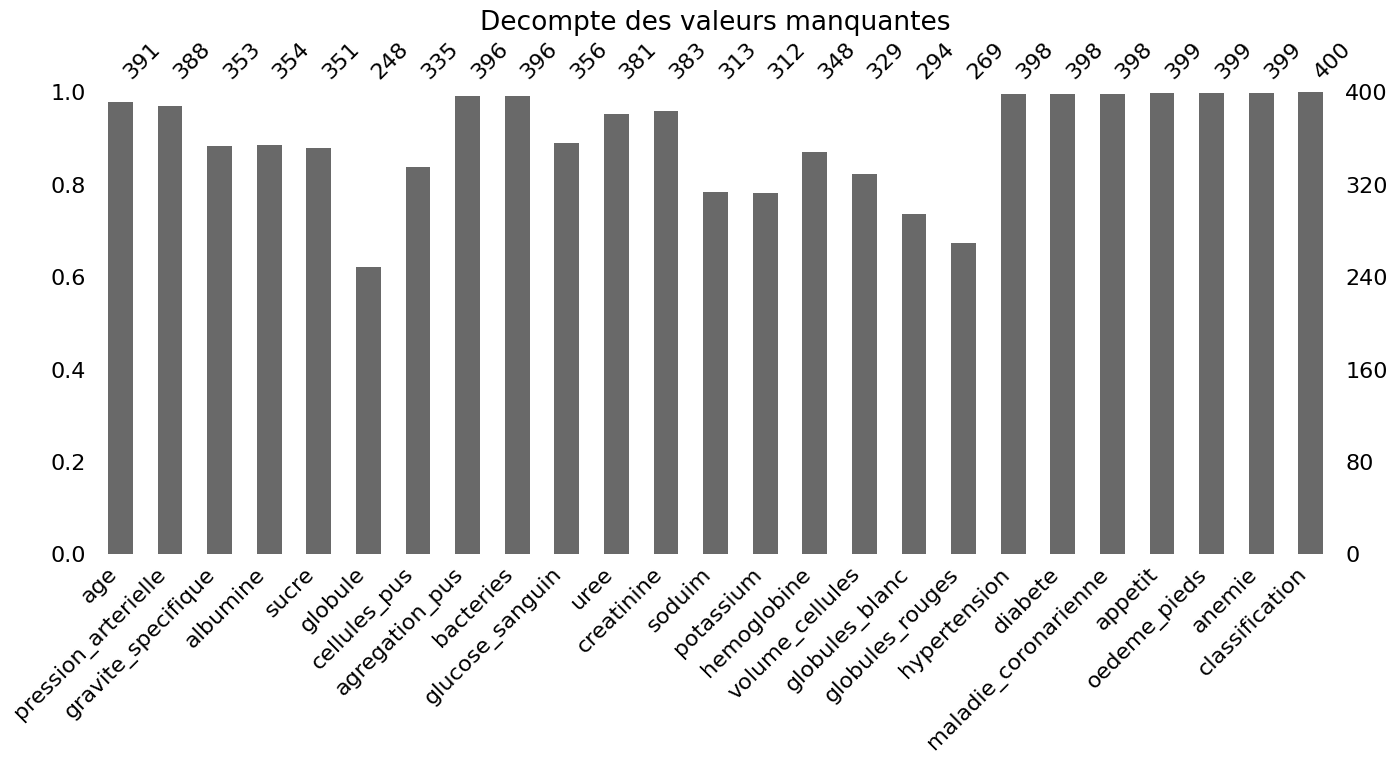

In [59]:
#graphique en barres 
msno.bar(ckd_clean,figsize=(16,6))
plt.title('Decompte des valeurs manquantes',fontsize =19)
plt.show(

)

#### Observation Clé 1 (Déséquilibre) :
La plupart des variables catégorielles montrent un déséquilibre important entre les classes. 
Par exemple :

    globule, cellules_pus, agregation_pus, bacteries : La classe normal ou notpresent est largement dominante.

    maladie_coronarienne, anemie, oedeme_pieds : La classe no est très majoritaire.


Conclusion pour l'Imputation : L'imputation par le Mode pour les valeurs manquantes dans ces colonnes est une stratégie très sûre. Remplacer les NaN par la classe dominante ne va faire que renforcer légèrement la distribution existante, ce qui est acceptable ici.

Observation Clé 2 (Cible) : La variable cible (classification) est raisonnablement équilibrée (ckd vs notckd), mais montre un léger déséquilibre en faveur de ckd (maladie rénale chronique).Plus de 'no' que de 'yes',ce qui peut jouer sur le modele a entrainer

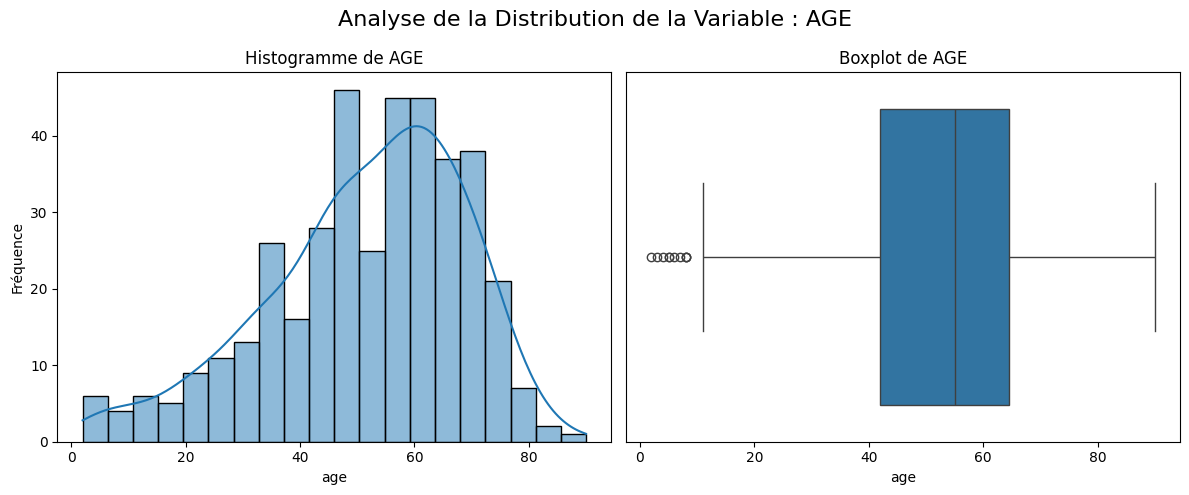

In [ ]:



# Nom de la variable à analyser
VAR = 'age'

plt.figure(figsize=(12, 5))
plt.suptitle(f"Analyse de la Distribution de la Variable : {VAR.upper()}", fontsize=16)

# Histogramme (Pour la forme de la distribution)
plt.subplot(1, 2, 1)
sns.histplot(x=ckd_clean[VAR].dropna(), kde=True, bins=20)
plt.title(f'Histogramme de {VAR.upper()}', fontsize=12)
plt.xlabel(VAR.replace("_", " "))
plt.ylabel("Fréquence")

# Boxplot (Pour la médiane, les quartiles et les outliers)
plt.subplot(1, 2, 2)
sns.boxplot(x=ckd_clean[VAR].dropna())
plt.title(f'Boxplot de {VAR.upper()}', fontsize=12)
plt.xlabel(VAR.replace("_", " "))
plt.yticks([])

plt.tight_layout()
plt.show()

Histogramme

    Forme : La distribution est relativement symétrique et ressemble approximativement à une courbe normale (en cloche), bien qu'elle soit légèrement asymétrique à gauche (skewness négative), avec une queue plus courte vers les âges jeunes.

    Tendance Centrale : La majorité des patients se situent entre 40 et 70 ans.
    

Boxplot

    Outliers : Il y a quelques points isolés à gauche (vers 10 ans), indiquant la présence de quelques patients très jeunes. Pour un modèle médical, ces outliers sont généralement valides et doivent être conservés, car ils représentent des cas réels (CKD pédiatrique).

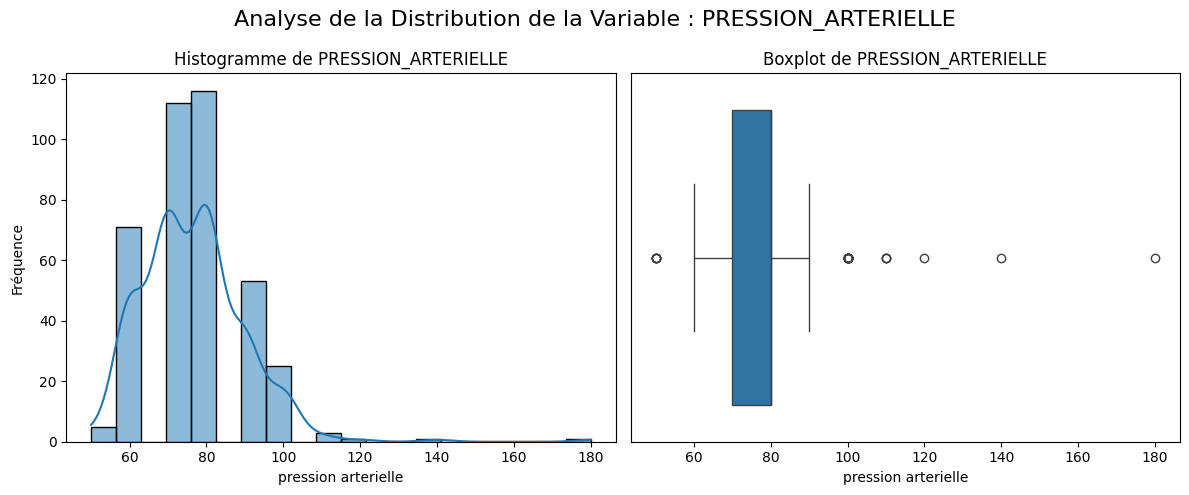

In [ ]:



# Nom de la variable à analyser
VAR = 'pression_arterielle'

plt.figure(figsize=(12, 5))
plt.suptitle(f"Analyse de la Distribution de la Variable : {VAR.upper()}", fontsize=16)

# Histogramme (Pour la forme de la distribution)
plt.subplot(1, 2, 1)
sns.histplot(x=ckd_clean[VAR].dropna(), kde=True, bins=20)
plt.title(f'Histogramme de {VAR.upper()}', fontsize=12)
plt.xlabel(VAR.replace("_", " "))
plt.ylabel("Fréquence")

# Boxplot (Pour la médiane, les quartiles et les outliers)
plt.subplot(1, 2, 2)
sns.boxplot(x=ckd_clean[VAR].dropna())
plt.title(f'Boxplot de {VAR.upper()}', fontsize=12)
plt.xlabel(VAR.replace("_", " "))
plt.yticks([])

plt.tight_layout()
plt.show()

Histogramme 

    Forme : La distribution est nettement asymétrique positivement (skewness à droite).

    Tendance Centrale : La majorité des mesures se concentrent autour de 70-80 mmHg. La queue s'étend loin vers la droite (100 à 180 mmHg).


Boxplot

    Outliers : Plusieurs points isolés sont visibles à droite (au-delà de 100 mmHg, jusqu'à 180 mmHg). Ces valeurs sont des hypertensions réelles et sont des indicateurs clés de la maladie rénale chronique. Ils ne doivent pas être retirés.


Conclusion pour le Prétraitement

    Transformation : Bien qu'il y ait de l'asymétrie, la pression artérielle est une variable avec des limites cliniques bien définies. Une transformation n'est généralement pas nécessaire ou est légère, car les valeurs extrêmes sont cliniquement significatives.

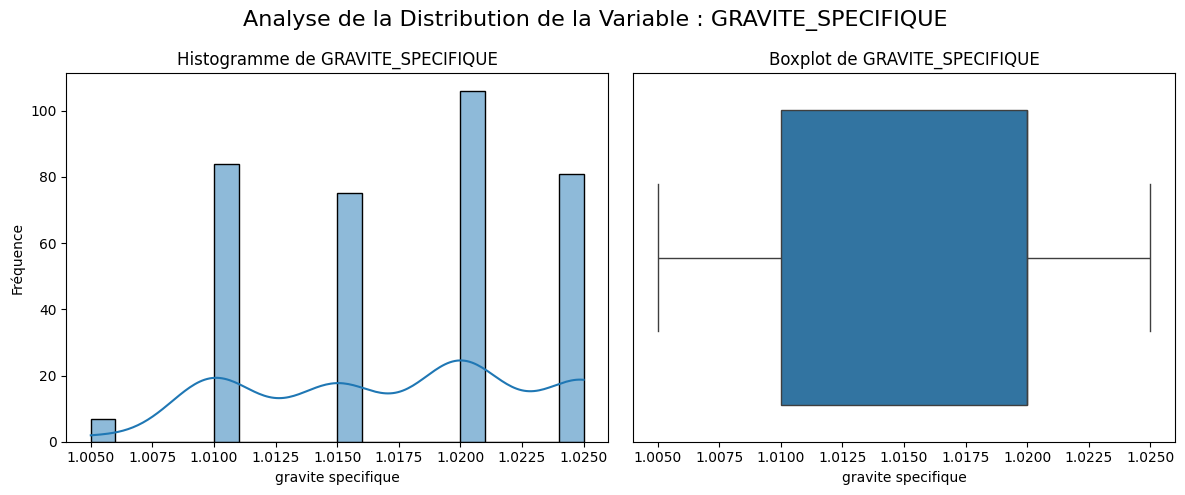

In [ ]:
# Nom de la variable à analyser
VAR = 'gravite_specifique'

plt.figure(figsize=(12, 5))
plt.suptitle(f"Analyse de la Distribution de la Variable : {VAR.upper()}", fontsize=16)

#  Histogramme (Pour la forme de la distribution)
plt.subplot(1, 2, 1)
sns.histplot(x=ckd_clean[VAR].dropna(), kde=True, bins=20)
plt.title(f'Histogramme de {VAR.upper()}', fontsize=12)
plt.xlabel(VAR.replace("_", " "))
plt.ylabel("Fréquence")

#  Boxplot (Pour la médiane, les quartiles et les outliers)
plt.subplot(1, 2, 2)
sns.boxplot(x=ckd_clean[VAR].dropna())
plt.title(f'Boxplot de {VAR.upper()}', fontsize=12)
plt.xlabel(VAR.replace("_", " "))
plt.yticks([])

plt.tight_layout()
plt.show()

Histogramme (image_3b2cf5.png)

    Forme : Il ne s'agit pas d'une distribution continue, mais d'une distribution discrète (catégorielle ordinale) avec seulement quelques valeurs possibles (1.010, 1.015, 1.020, 1.025). Le fait qu'elle soit traitée comme numérique dans le boxplot est une conséquence des types de données du fichier source.

    Tendance : Les valeurs les plus fréquentes sont 1.010 et 1.020.

Boxplot

    Outliers : La boîte large et l'absence de points isolés indiquent que les données sont regroupées sur les valeurs discrètes.

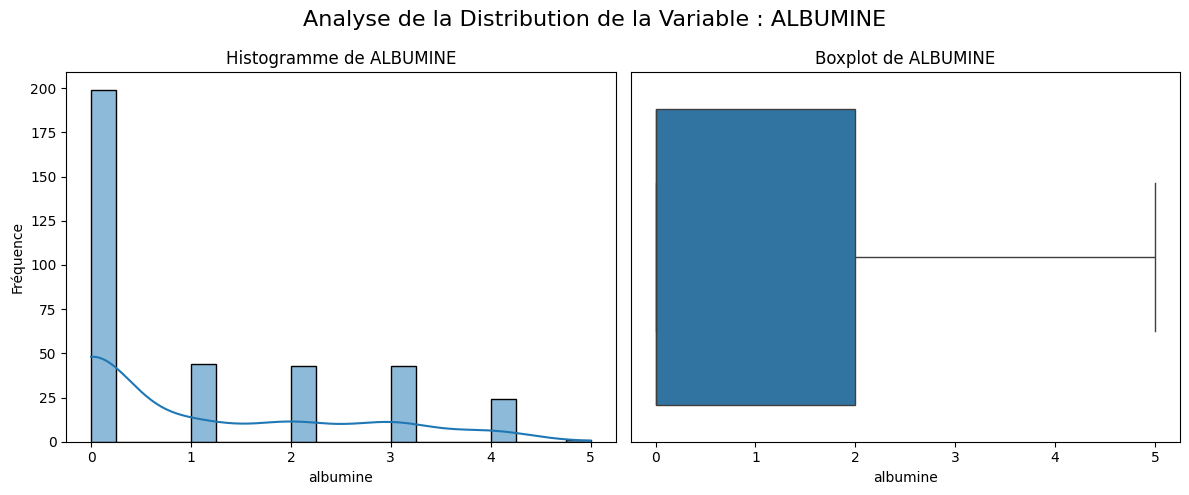

In [ ]:

# Nom de la variable à analyser
VAR = 'albumine'

plt.figure(figsize=(12, 5))
plt.suptitle(f"Analyse de la Distribution de la Variable : {VAR.upper()}", fontsize=16)

#  Histogramme (Pour la forme de la distribution)
plt.subplot(1, 2, 1)
sns.histplot(x=ckd_clean[VAR].dropna(), kde=True, bins=20)
plt.title(f'Histogramme de {VAR.upper()}', fontsize=12)
plt.xlabel(VAR.replace("_", " "))
plt.ylabel("Fréquence")

# Boxplot (Pour la médiane, les quartiles et les outliers)
plt.subplot(1, 2, 2)
sns.boxplot(x=ckd_clean[VAR].dropna())
plt.title(f'Boxplot de {VAR.upper()}', fontsize=12)
plt.xlabel(VAR.replace("_", " "))
plt.yticks([])

plt.tight_layout()
plt.show()

Forme (Histogramme)	
Distribution très discrète (en forme de L ou en barres) avec des pics à 0, 1, 2, 3, 4, 5. La valeur 0 est de loin la plus fréquente.	Ces variables ne sont pas continues; elles représentent des niveaux de mesure (quantifiés). Elles doivent être traitées comme numériques discrètes pour l'imputation, mais comme catégorielles ordinales pour certaines analyses.

Outliers (Boxplot)	
Le boxplot est concentré sur les niveaux de 0 à 2. Les valeurs sont réparties sur ces niveaux.	Confirme que ces niveaux sont les seules valeurs dans le jeu de données, renforçant l'idée qu'elles représentent un score ou un niveau, et non une mesure continue.

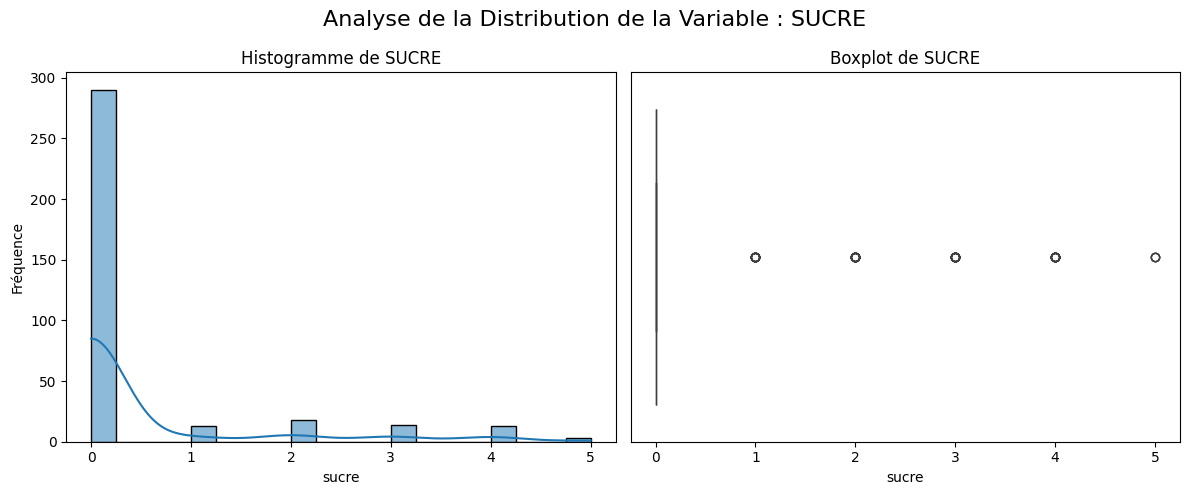

In [ ]:

# Nom de la variable à analyser
VAR = 'sucre'

plt.figure(figsize=(12, 5))
plt.suptitle(f"Analyse de la Distribution de la Variable : {VAR.upper()}", fontsize=16)

#  Histogramme (Pour la forme de la distribution)
plt.subplot(1, 2, 1)
sns.histplot(x=ckd_clean[VAR].dropna(), kde=True, bins=20)
plt.title(f'Histogramme de {VAR.upper()}', fontsize=12)
plt.xlabel(VAR.replace("_", " "))
plt.ylabel("Fréquence")

# Boxplot (Pour la médiane, les quartiles et les outliers)
plt.subplot(1, 2, 2)
sns.boxplot(x=ckd_clean[VAR].dropna())
plt.title(f'Boxplot de {VAR.upper()}', fontsize=12)
plt.xlabel(VAR.replace("_", " "))
plt.yticks([])

plt.tight_layout()
plt.show()

Forme (Histogramme)	
Distribution très discrète (en forme de L ou en barres) avec des pics à 0, 1, 2, 3, 4, 5. La valeur 0 est de loin la plus fréquente.	Ces variables ne sont pas continues; elles représentent des niveaux de mesure (quantifiés). Elles doivent être traitées comme numériques discrètes pour l'imputation, mais comme catégorielles ordinales pour certaines analyses.

Outliers (Boxplot)
	Le boxplot est concentré sur les niveaux de 0 à 5. Les valeurs sont réparties sur ces niveaux.	Confirme que ces niveaux sont les seules valeurs dans le jeu de données, renforçant l'idée qu'elles représentent un score ou un niveau, et non une mesure continue.

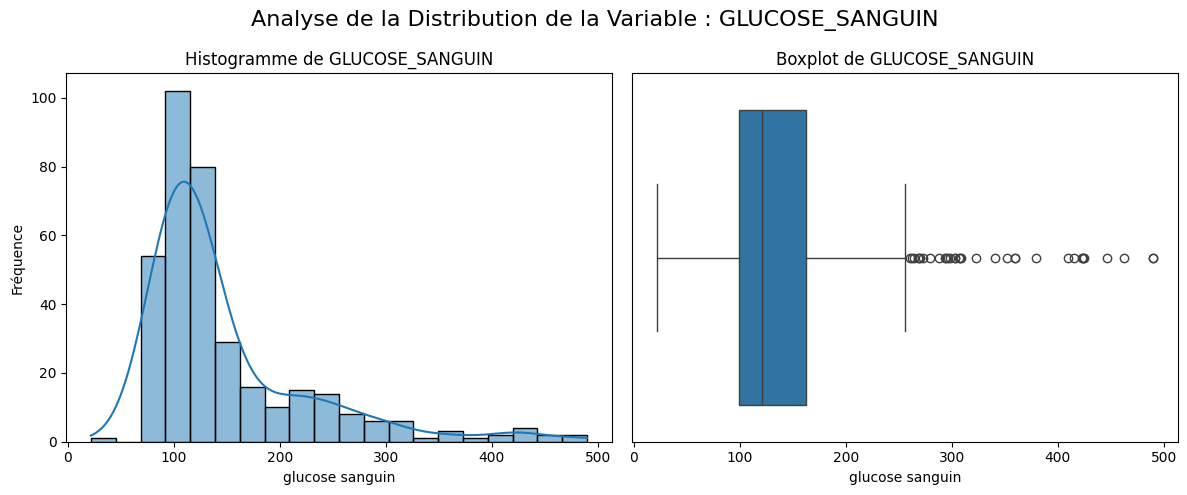

In [ ]:

# Nom de la variable à analyser
VAR = 'glucose_sanguin'

plt.figure(figsize=(12, 5))
plt.suptitle(f"Analyse de la Distribution de la Variable : {VAR.upper()}", fontsize=16)

#  Histogramme (Pour la forme de la distribution)
plt.subplot(1, 2, 1)
sns.histplot(x=ckd_clean[VAR].dropna(), kde=True, bins=20)
plt.title(f'Histogramme de {VAR.upper()}', fontsize=12)
plt.xlabel(VAR.replace("_", " "))
plt.ylabel("Fréquence")

# Boxplot (Pour la médiane, les quartiles et les outliers)
plt.subplot(1, 2, 2)
sns.boxplot(x=ckd_clean[VAR].dropna())
plt.title(f'Boxplot de {VAR.upper()}', fontsize=12)
plt.xlabel(VAR.replace("_", " "))
plt.yticks([])

plt.tight_layout()
plt.show()

Histogramme (Forme de la Distribution)

    Observation : La distribution présente une asymétrie positive très forte (strong positive skewness).

    Signification : La grande majorité des patients se concentrent autour des valeurs normales de glycémie (probablement entre 70 et 120 mg/dL). Cependant, il y a une longue queue s'étendant loin vers la droite, indiquant une minorité de patients avec des niveaux de glucose très élevés (supérieurs à 200, voire 400 mg/dL).

    Interprétation Clinique : Cette queue représente les patients atteints de diabète ou ayant une intolérance au glucose sévère.
    

2. Boxplot (Dispersion et Valeurs Extrêmes)

    Observation : Le boxplot est très compact du côté gauche, mais affiche de nombreux points isolés (outliers) s'étendant vers la droite (jusqu'à la limite supérieure de l'axe).

    Signification : Les outliers confirment l'existence de valeurs extrêmes. Contrairement aux erreurs de saisie, ces valeurs sont cliniquement valides et extrêmement informatives.

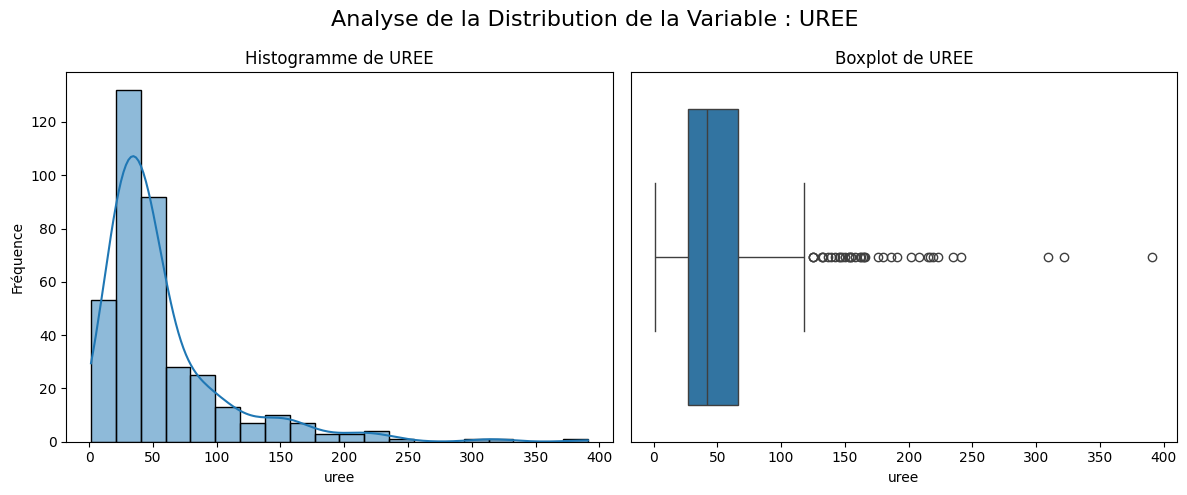

In [ ]:

# Nom de la variable à analyser
VAR = 'uree'

plt.figure(figsize=(12, 5))
plt.suptitle(f"Analyse de la Distribution de la Variable : {VAR.upper()}", fontsize=16)

#  Histogramme (Pour la forme de la distribution)
plt.subplot(1, 2, 1)
sns.histplot(x=ckd_clean[VAR].dropna(), kde=True, bins=20)
plt.title(f'Histogramme de {VAR.upper()}', fontsize=12)
plt.xlabel(VAR.replace("_", " "))
plt.ylabel("Fréquence")

# Boxplot (Pour la médiane, les quartiles et les outliers)
plt.subplot(1, 2, 2)
sns.boxplot(x=ckd_clean[VAR].dropna())
plt.title(f'Boxplot de {VAR.upper()}', fontsize=12)
plt.xlabel(VAR.replace("_", " "))
plt.yticks([])

plt.tight_layout()
plt.show()

Histogramme (Forme de la Distribution)

    Observation : La distribution de l'urée présente une asymétrie positive très forte (severe positive skewness).

    Signification : La grande majorité des valeurs se concentrent à l'extrémité gauche (faibles niveaux d'urée, typiques d'une fonction rénale normale). Cependant, il y a une longue et épaisse queue s'étendant vers la droite (jusqu'à 400 mg/dL et au-delà).

    Interprétation Clinique : Cette queue représente les patients souffrant d'azotémie ou d'insuffisance rénale sévère, où les reins ne parviennent plus à filtrer efficacement l'urée, provoquant son accumulation dans le sang. Plus l'urée est élevée, plus l'indication de maladie rénale est forte.


. Boxplot (Dispersion et Valeurs Extrêmes)

    Observation : La boîte principale est compacte (distribution serrée des valeurs normales), mais le boxplot affiche de nombreux points isolés (outliers) s'étalant jusqu'à l'extrémité droite du graphique.

    Signification : Ces outliers sont des valeurs extrêmes de l'urée. Ils sont cliniquement valides (représentent des cas réels de maladie avancée) et sont des indicateurs extrêmement puissants.

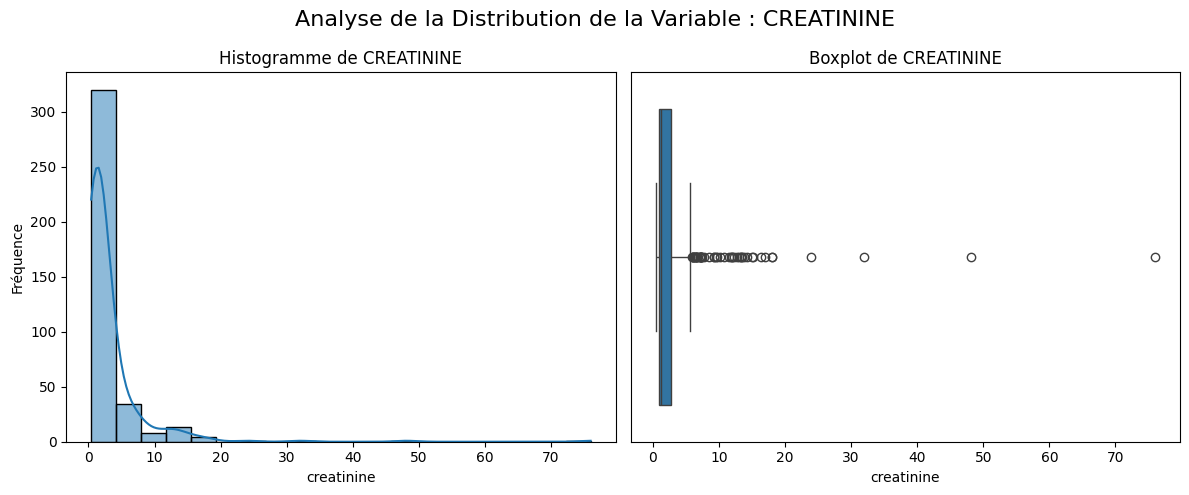

In [ ]:

# Nom de la variable à analyser
VAR = 'creatinine'

plt.figure(figsize=(12, 5))
plt.suptitle(f"Analyse de la Distribution de la Variable : {VAR.upper()}", fontsize=16)

#  Histogramme (Pour la forme de la distribution)
plt.subplot(1, 2, 1)
sns.histplot(x=ckd_clean[VAR].dropna(), kde=True, bins=20)
plt.title(f'Histogramme de {VAR.upper()}', fontsize=12)
plt.xlabel(VAR.replace("_", " "))
plt.ylabel("Fréquence")

#  Boxplot (Pour la médiane, les quartiles et les outliers)
plt.subplot(1, 2, 2)
sns.boxplot(x=ckd_clean[VAR].dropna())
plt.title(f'Boxplot de {VAR.upper()}', fontsize=12)
plt.xlabel(VAR.replace("_", " "))
plt.yticks([])

plt.tight_layout()
plt.show()

Histogramme & Asymétrie

    Observation : La distribution est extrêmement asymétrique positivement (extreme positive skewness).

    Signification : La majorité des patients ont des niveaux bas (fonction rénale normale), mais la longue queue à droite (s'étendant jusqu'à 70 mg/dL) représente les cas de maladie rénale sévère (insuffisance rénale).


 Boxplot & Outliers

    Observation : La boîte est très compacte, et de nombreux outliers (points isolés) s'étendent sur toute la plage de valeurs.

    Conclusion : Ces outliers sont des indicateurs pathologiques cruciaux et doivent être conservés.

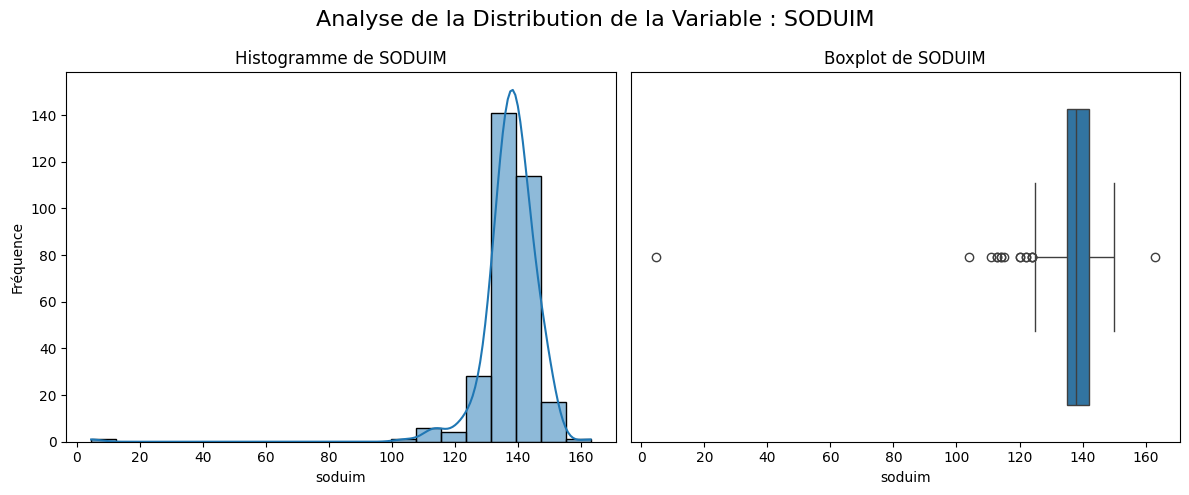

In [ ]:

# Nom de la variable à analyser
VAR = 'soduim'

plt.figure(figsize=(12, 5))
plt.suptitle(f"Analyse de la Distribution de la Variable : {VAR.upper()}", fontsize=16)

#  Histogramme (Pour la forme de la distribution)
plt.subplot(1, 2, 1)
sns.histplot(x=ckd_clean[VAR].dropna(), kde=True, bins=20)
plt.title(f'Histogramme de {VAR.upper()}', fontsize=12)
plt.xlabel(VAR.replace("_", " "))
plt.ylabel("Fréquence")

#  Boxplot (Pour la médiane, les quartiles et les outliers)
plt.subplot(1, 2, 2)
sns.boxplot(x=ckd_clean[VAR].dropna())
plt.title(f'Boxplot de {VAR.upper()}', fontsize=12)
plt.xlabel(VAR.replace("_", " "))
plt.yticks([])

plt.tight_layout()
plt.show()

Histogramme (Forme de la Distribution)

    Observation : La distribution du sodium est symétrique et très concentrée (étroite), ressemblant de près à une courbe normale (en cloche) centrée autour des valeurs normales de 135 à 145 mEq/L.

    Signification : Cela indique que, pour la majorité des échantillons non manquants, le sodium suit un modèle de distribution attendu.

 Boxplot (Dispersion et Valeurs Extrêmes)

    Observation : Le boxplot est compact, mais il y a des points isolés (outliers) aux deux extrémités de l'axe :

        À gauche (vers 120 ou moins) : représente l'hyponatrémie (faible taux de sodium).

        À droite (vers 150 ou plus) : représente l'hypernatrémie (taux élevé de sodium).

    Signification Clinique : Les deux extrêmes sont des déséquilibres électrolytiques qui peuvent être causés ou aggravés par la CKD. Ils sont donc cliniquement valides et doivent être conservés.

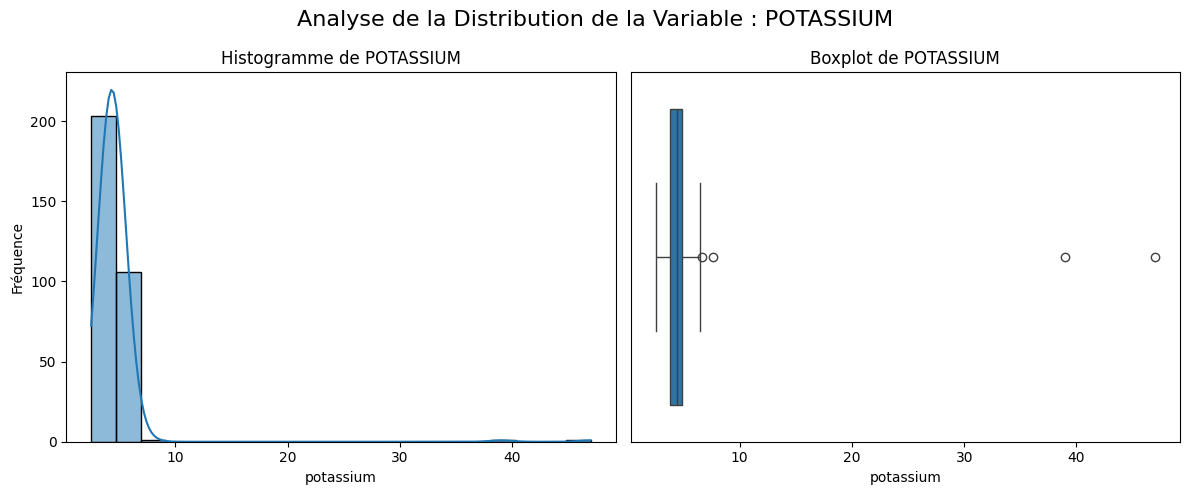

In [ ]:

# Nom de la variable à analyser
VAR = 'potassium'

plt.figure(figsize=(12, 5))
plt.suptitle(f"Analyse de la Distribution de la Variable : {VAR.upper()}", fontsize=16)

#  Histogramme (Pour la forme de la distribution)
plt.subplot(1, 2, 1)
sns.histplot(x=ckd_clean[VAR].dropna(), kde=True, bins=20)
plt.title(f'Histogramme de {VAR.upper()}', fontsize=12)
plt.xlabel(VAR.replace("_", " "))
plt.ylabel("Fréquence")

#  Boxplot (Pour la médiane, les quartiles et les outliers)
plt.subplot(1, 2, 2)
sns.boxplot(x=ckd_clean[VAR].dropna())
plt.title(f'Boxplot de {VAR.upper()}', fontsize=12)
plt.xlabel(VAR.replace("_", " "))
plt.yticks([])

plt.tight_layout()
plt.show()

 Histogramme (Forme de la Distribution)

    Observation : La distribution du potassium présente une asymétrie positive extrême (extreme positive skewness).

    Signification : La grande majorité des échantillons se concentrent dans la plage normale (entre 3.5 et 5.0 mEq/L). Cependant, la distribution a une longue queue qui s'étire très loin vers la droite, indiquant des valeurs pathologiquement élevées (jusqu'à 40 ou plus).

    Interprétation Clinique : Ces valeurs très élevées représentent l'hyperkaliémie (excès de potassium), un signe fréquent et dangereux d'une insuffisance rénale avancée, car les reins n'éliminent plus correctement le potassium.

 Boxplot (Dispersion et Valeurs Extrêmes)

    Observation : La boîte est très étroite, et le graphique affiche des points isolés massifs s'étendant bien au-delà de la concentration normale.

    Signification : Ces outliers sont des données cliniques cruciales. Ils confirment que la variable est un indicateur puissant de maladie et doivent être conservés.

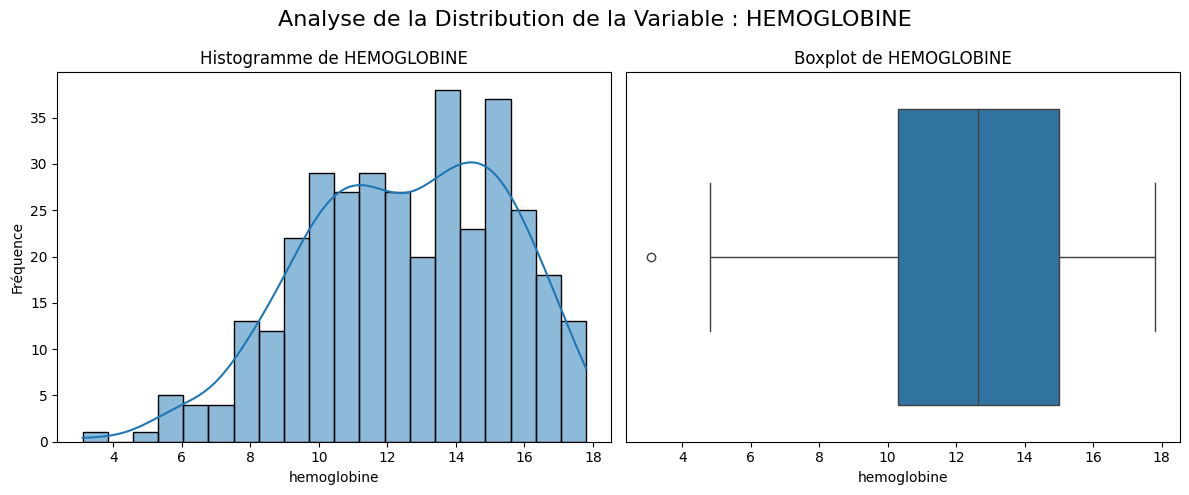

In [ ]:

# Nom de la variable à analyser
VAR = 'hemoglobine'

plt.figure(figsize=(12, 5))
plt.suptitle(f"Analyse de la Distribution de la Variable : {VAR.upper()}", fontsize=16)

#  Histogramme (Pour la forme de la distribution)
plt.subplot(1, 2, 1)
sns.histplot(x=ckd_clean[VAR].dropna(), kde=True, bins=20)
plt.title(f'Histogramme de {VAR.upper()}', fontsize=12)
plt.xlabel(VAR.replace("_", " "))
plt.ylabel("Fréquence")

#  Boxplot (Pour la médiane, les quartiles et les outliers)
plt.subplot(1, 2, 2)
sns.boxplot(x=ckd_clean[VAR].dropna())
plt.title(f'Boxplot de {VAR.upper()}', fontsize=12)
plt.xlabel(VAR.replace("_", " "))
plt.yticks([])

plt.tight_layout()
plt.show()

Histogramme (Forme de la Distribution)

    Observation : La distribution de l'hémoglobine est relativement symétrique et en forme de cloche, bien qu'elle soit légèrement platykurtique (moins pointue que la courbe normale) ou bimodale (avec un léger creux au centre).

    Signification : La distribution est centrée autour des valeurs normales de 13 à 14 g/dL, mais elle s'étale des deux côtés, capturant à la fois les cas d'anémie (valeurs basses) et les cas normaux/élevés.

    Interprétation Clinique : La distribution n'est pas fortement asymétrique, mais elle couvre une large plage, ce qui est attendu dans une cohorte de patients CKD où l'anémie est courante.

 Boxplot (Dispersion et Valeurs Extrêmes)

    Observation : Le boxplot est centré et présente une boîte large, ce qui indique une bonne dispersion des données. Il n'y a qu'un seul outlier isolé et faible (autour de 4 g/dL).

    Signification Clinique : Ce point isolé représente probablement un cas d'anémie très sévère, cliniquement très pertinent. L'absence d'asymétrie extrême confirme que la majorité des patients n'ont pas des valeurs hors de l'intervalle clinique attendu.

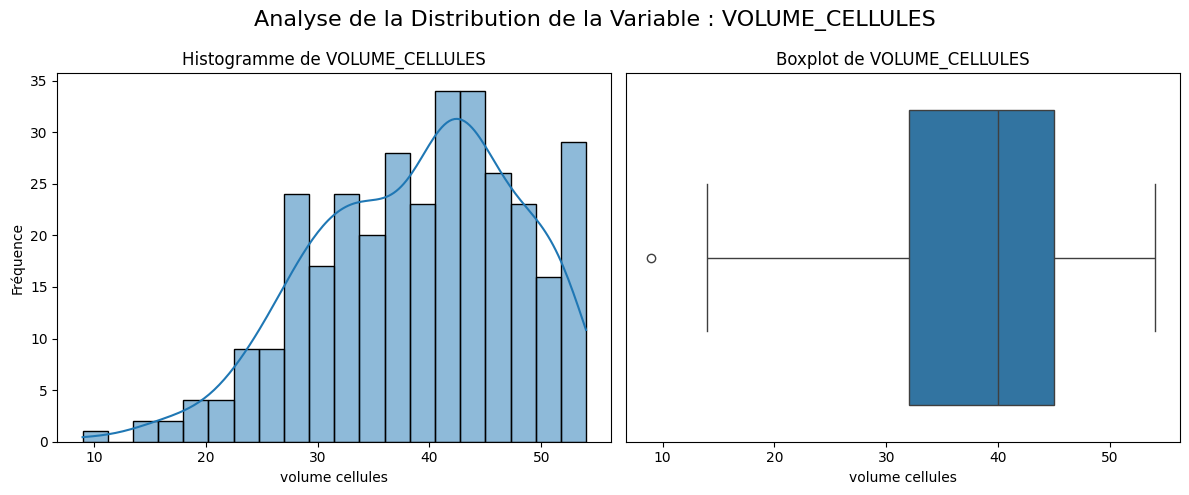

In [ ]:

# Nom de la variable à analyser
VAR = 'volume_cellules'

plt.figure(figsize=(12, 5))
plt.suptitle(f"Analyse de la Distribution de la Variable : {VAR.upper()}", fontsize=16)

#  Histogramme (Pour la forme de la distribution)
plt.subplot(1, 2, 1)
sns.histplot(x=ckd_clean[VAR].dropna(), kde=True, bins=20)
plt.title(f'Histogramme de {VAR.upper()}', fontsize=12)
plt.xlabel(VAR.replace("_", " "))
plt.ylabel("Fréquence")

#  Boxplot (Pour la médiane, les quartiles et les outliers)
plt.subplot(1, 2, 2)
sns.boxplot(x=ckd_clean[VAR].dropna())
plt.title(f'Boxplot de {VAR.upper()}', fontsize=12)
plt.xlabel(VAR.replace("_", " "))
plt.yticks([])

plt.tight_layout()
plt.show()

Histogramme (Forme de la Distribution)

    Observation : La distribution du volume des cellules est relativement symétrique et en forme de cloche.

    Signification : La majorité des patients se regroupent autour de la plage normale (environ 40 à 45%). L'étalement vers la gauche indique la présence de l'anémie (faible hématocrite), très courante chez les patients atteints de Maladie Rénale Chronique (CKD).

    Interprétation Clinique : La forme symétrique est une bonne nouvelle pour la modélisation et est cohérente avec les résultats de l'Hémoglobine.

 Boxplot (Dispersion et Valeurs Extrêmes)

    Observation : Le boxplot est bien centré avec une bonne dispersion. Il y a un seul outlier isolé et faible (autour de 15%).

    Signification Clinique : Cet outlier représente un cas d'anémie sévère, cliniquement très pertinent.

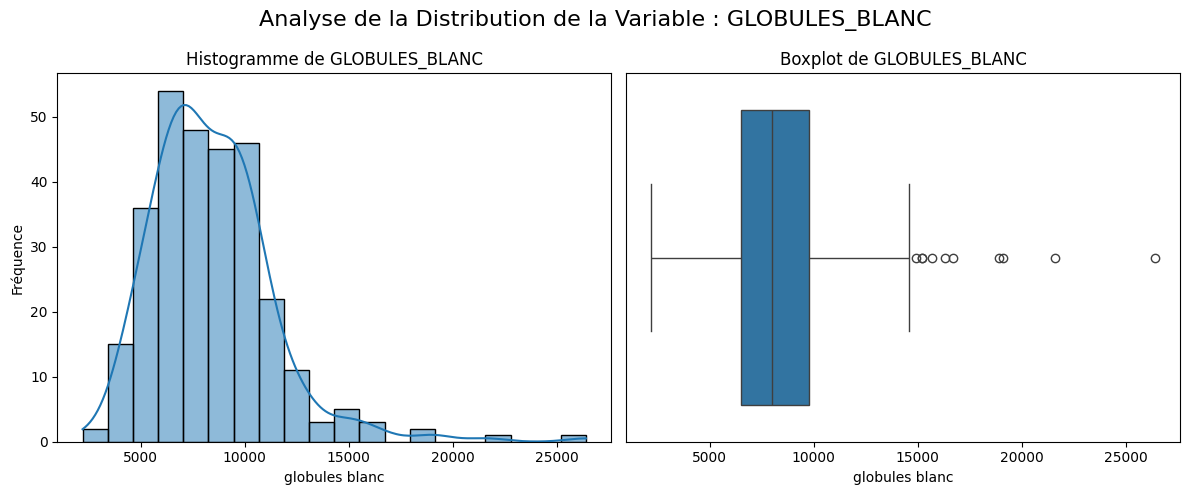

In [ ]:

# Nom de la variable à analyser
VAR = 'globules_blanc'

plt.figure(figsize=(12, 5))
plt.suptitle(f"Analyse de la Distribution de la Variable : {VAR.upper()}", fontsize=16)

#  Histogramme (Pour la forme de la distribution)
plt.subplot(1, 2, 1)
sns.histplot(x=ckd_clean[VAR].dropna(), kde=True, bins=20)
plt.title(f'Histogramme de {VAR.upper()}', fontsize=12)
plt.xlabel(VAR.replace("_", " "))
plt.ylabel("Fréquence")

#  Boxplot (Pour la médiane, les quartiles et les outliers)
plt.subplot(1, 2, 2)
sns.boxplot(x=ckd_clean[VAR].dropna())
plt.title(f'Boxplot de {VAR.upper()}', fontsize=12)
plt.xlabel(VAR.replace("_", " "))
plt.yticks([])

plt.tight_layout()
plt.show()

Histogramme (Forme de la Distribution)

    Observation : La distribution des globules blancs présente une asymétrie positive forte (strong positive skewness).

    Signification : La majorité des patients se situent dans la plage normale (entre 5 000 et 10 000/mm³). La longue queue à droite indique la présence d'un sous-groupe de patients avec une leucocytose (comptes élevés) due à une infection, une inflammation ou d'autres causes.

    Interprétation Clinique : Des comptes de globules blancs élevés sont pertinents pour la CKD, car l'inflammation chronique est un facteur aggravant.

   Boxplot (Dispersion et Valeurs Extrêmes)

    Observation : Le boxplot est compact, mais il y a de nombreux outliers (points isolés) qui s'étendent bien au-delà de 15 000/mm³, jusqu'à environ 25 000/mm³.

    Signification Clinique : Ces outliers représentent des cas d'hyperleucocytose et sont des données cliniques valides. Ils ne doivent pas être retirés.

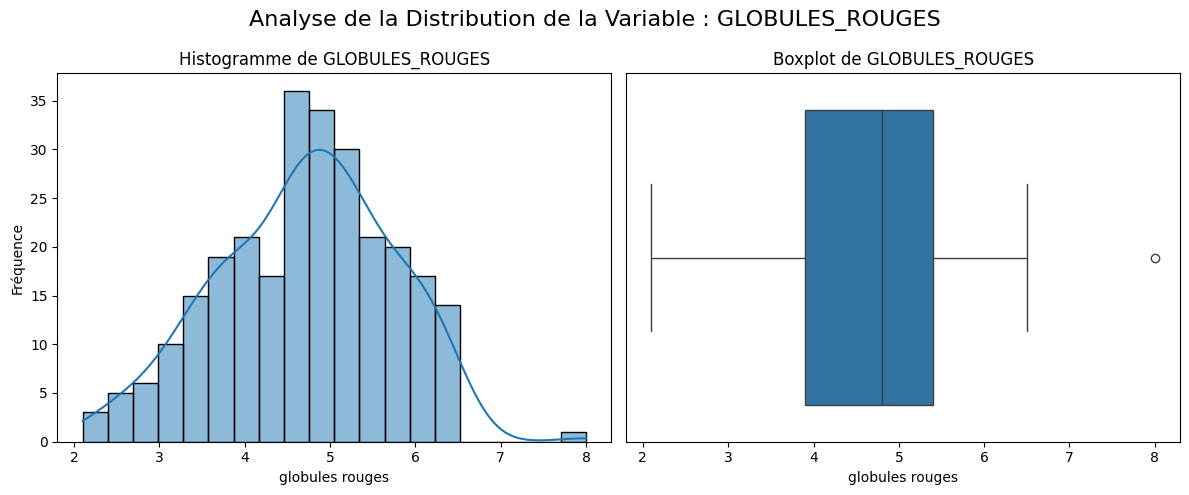

In [ ]:

# Nom de la variable à analyser
VAR = 'globules_rouges'

plt.figure(figsize=(12, 5))
plt.suptitle(f"Analyse de la Distribution de la Variable : {VAR.upper()}", fontsize=16)

#  Histogramme (Pour la forme de la distribution)
plt.subplot(1, 2, 1)
sns.histplot(x=ckd_clean[VAR].dropna(), kde=True, bins=20)
plt.title(f'Histogramme de {VAR.upper()}', fontsize=12)
plt.xlabel(VAR.replace("_", " "))
plt.ylabel("Fréquence")

#  Boxplot (Pour la médiane, les quartiles et les outliers)
plt.subplot(1, 2, 2)
sns.boxplot(x=ckd_clean[VAR].dropna())
plt.title(f'Boxplot de {VAR.upper()}', fontsize=12)
plt.xlabel(VAR.replace("_", " "))
plt.yticks([])

plt.tight_layout()
plt.show()

Histogramme (Forme de la Distribution)

    Observation : La distribution des globules rouges est relativement symétrique et en forme de cloche, bien qu'elle soit légèrement étalée.

    Signification : La majorité des patients se regroupent dans la plage normale (environ 4.0 à 6.0 millions/mm³).

    Interprétation Clinique : La distribution est saine pour la modélisation. L'étalement vers la gauche (valeurs basses) indique la présence de l'anémie, un symptôme attendu chez les patients atteints de Maladie Rénale Chronique (CKD).


 Boxplot (Dispersion et Valeurs Extrêmes)

    Observation : Le boxplot est bien centré et présente une dispersion normale. Il y a un seul outlier isolé à droite (autour de 8 millions/mm³).

    Signification Clinique : L'absence d'asymétrie extrême et de nombreux outliers confirme la bonne qualité de cette mesure. Le point isolé peut représenter un cas rare de polyglobulie (excès de globules rouges) ou une erreur, mais en général, la variable est bien comportementée.


##  Les Différenciateurs Critiques (Asymétrie Extrême)

Ces variables sont indispensables car leurs valeurs sont très basses chez les personnes saines, mais grimpent de façon exponentielle en cas de maladie rénale.

* ### **Créatinine**
    * **Raison :** Sa distribution est la plus asymétrique. Une valeur élevée est directement proportionnelle à une mauvaise fonction rénale. Elle est le marqueur le plus fiable du **débit de filtration glomérulaire (DFG)**.
* ### **Urée**
    * **Raison :** Très forte asymétrie positive. Comme la créatinine, l'accumulation d'urée dans le sang (**azotémie**) est un signe direct de la défaillance de la filtration rénale.
* ### **Potassium**
    * **Raison :** Asymétrie extrême. Les reins régulent le potassium. Une hyperkaliémie (Potassium très élevé) est une complication fréquente et dangereuse de la CKD.
* ### **Glucose Sanguin**
    * **Raison :** Forte asymétrie positive. Bien que ce ne soit pas un marqueur direct de la fonction rénale, des valeurs élevées indiquent le **diabète**, qui est la cause principale de la CKD.

---

##  Les Différenciateurs de Gravité (Variables Discrètes)

Ces variables, traitées comme numériques dans les graphiques, sont en réalité des **scores** ou des **niveaux discrets**. Le passage d'une valeur de **0** (normal) à **1, 2, 3 ou plus** est un signal extrêmement fort de la maladie.

* ### **Albumine**
    * **Raison :** La distribution est en forme de 'L', avec un pic à **0**. L'albumine dans l'urine (**albuminurie**) est l'un des premiers signes de dommage rénal. Toute valeur supérieure à 0 est un signal critique.
* ### **Sucre (dans l'urine)**
    * **Raison :** Similaire à l'albumine. La présence de sucre dans l'urine, même en l'absence de diabète diagnostiqué, indique un problème de réabsorption rénale.

---

##  Les Différenciateurs de Complication (Anémie)

Ces variables symétriques montrent l'impact de la CKD sur la production de sang (l'anémie).

* ### **Hémoglobine et Volume Cellulaire (Hématocrite)**
    * **Raison :** Bien que symétriques, des valeurs basses (à gauche de la médiane) indiquent l'**anémie**, une complication fréquente de la CKD due au manque de production d'érythropoïétine (EPO) par les reins.
* ### **Globules Rouges**
    * **Raison :** Similaire à l'hémoglobine, des valeurs basses signalent une anémie.

**Conclusion :**

Pour différencier les malades des non-malades, nous allons nous concentrer sur le groupe **Créatinine, Urée, Potassium** (pour la fonction rénale) et **Albumine, Sucre** (pour les dommages précoces). Ces variables présentent les plus grandes variations pathologiques dans leur distribution.

### Imputation

### Analyse Exploratoire Preliminaire sans les NaN apres Imputation